Dataset Setup and Structure Handling

In [82]:
import mne
base_path = "data"
subjects = ["sub-LTP063", "sub-LTP064", "sub-LTP065"]
sessions = ["ses-10", "ses-2"]

X_all = []  #feature matrix
y_all = []  #labels
bands = {
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (13, 30)
}

In [83]:
import os
os.getcwd()
os.listdir()

['.ipynb_checkpoints',
 'anaconda_projects',
 'CHANGES',
 'code.py',
 'data',
 'dataset_description.json',
 'memory_model.pkl',
 'NMM.ipynb',
 'notebooks',
 'participants.json',
 'participants.tsv',
 'README',
 'scaler.pkl',
 'stimuli']

In [84]:
import os
import mne
import pandas as pd
import numpy as np

for subject in subjects:
    for session in sessions:

        eeg_path = os.path.join(base_path, subject, session, "eeg")

        print("Processing:", subject, session)

        files = os.listdir(eeg_path)

        eeg_file = [f for f in files if f.endswith("task-ltpFR_eeg.edf")][0]
        event_file = [f for f in files if f.endswith("task-ltpFR_events.tsv")][0]

        eeg_file = os.path.join(eeg_path, eeg_file)
        event_file = os.path.join(eeg_path, event_file)

        # -----------------------------
        # Load EEG
        # -----------------------------
        raw = mne.io.read_raw_edf(eeg_file, preload=True)

        montage = mne.channels.make_standard_montage("GSN-HydroCel-129")
        raw.set_montage(montage, on_missing="ignore")

        raw.filter(0.5, 40)

        # Remove bad channel
        if "E129" in raw.ch_names:
            raw.info['bads'] = ['E129']
            raw.drop_channels(['E129'])

        # -----------------------------
        # Load events
        # -----------------------------
        events = pd.read_csv(event_file, sep="\t")

        rec_events = events[
            (events["trial_type"] == "REC_WORD") |
            (events["trial_type"] == "REC_WORD_VV")
        ]

        if len(rec_events) == 0:
            continue

        # -----------------------------
        # Create MNE events array
        # -----------------------------
        events_array = np.column_stack((
            rec_events["sample"].values,
            np.zeros(len(rec_events), dtype=int),
            np.ones(len(rec_events), dtype=int)
        ))

        event_id = {"recall": 1}

        # -----------------------------
        # Epoch extraction
        # -----------------------------
        epochs = mne.Epochs(
            raw,
            events_array,
            event_id,
            tmin=-1,
            tmax=1,
            preload=True
        )

        # -----------------------------
        # Compute PSD
        # -----------------------------
        psd = epochs.compute_psd(fmin=4, fmax=30)

        psd_data = psd.get_data()
        freqs = psd.freqs

        # -----------------------------
        # Extract band power features
        # -----------------------------
        band_features = []

        for band, (fmin, fmax) in bands.items():

            freq_mask = (freqs >= fmin) & (freqs <= fmax)

            band_power = psd_data[:, :, freq_mask].mean(axis=2)

            band_features.append(band_power)

        # Combine bands
        X = np.concatenate(band_features, axis=1)

        # -----------------------------
        # Labels
        # -----------------------------
        labels = rec_events["item_num"].values
        y = (labels > 0).astype(int)

        X_all.append(X)
        y_all.append(y)

Processing: sub-LTP063 ses-10
Extracting EDF parameters from data\sub-LTP063\ses-10\eeg\sub-LTP063_ses-10_task-ltpFR_eeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 2122999  =      0.000 ...  4245.998 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3301 samples (6.602 s)

Not setting metadata
115 matching events found
Setting baseline interval to [-1.0, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloade

In [91]:
import numpy as np
print(np.unique(y_all, return_counts=True))

(array([0, 1]), array([ 24, 872]))


In [93]:
brain_regions = {
    "frontal": list(range(0, 25)),
    "temporal": list(range(25, 50)),
    "parietal": list(range(50, 75)),
    "occipital": list(range(75, 100)),
    "central": list(range(100, 128))
}

In [94]:
def map_brain_regions(X):

    region_features = []

    for band in range(3):

        start = band * 128
        end = start + 128
        band_data = X[:, start:end]

        for region in brain_regions.values():

            region_mean = band_data[:, region].mean(axis=1)

            region_features.append(region_mean)

    return np.column_stack(region_features)

In [95]:
X_region = map_brain_regions(X_all)

print(X_region.shape)

(896, 15)


In [96]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [99]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    class_weight="balanced",
    probability=True
)

svm.fit(X_train_bal, y_train_bal)

pred = svm.predict(X_test)

In [100]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.10      0.40      0.15         5
           1       0.98      0.91      0.94       202

    accuracy                           0.89       207
   macro avg       0.54      0.65      0.55       207
weighted avg       0.96      0.89      0.92       207



In [101]:
from sklearn.metrics import roc_auc_score

probs = svm.predict_proba(X_test)[:,1]

print("ROC AUC:", roc_auc_score(y_test, probs))

ROC AUC: 0.7831683168316832


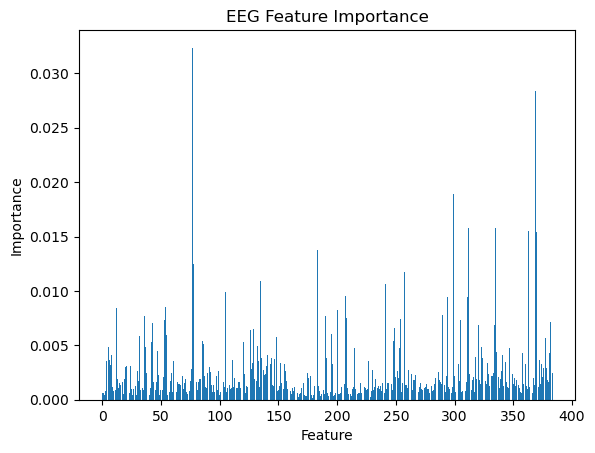

In [102]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_

plt.bar(range(len(importances)), importances)
plt.title("EEG Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()

In [104]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [105]:
print(np.unique(y_train_bal, return_counts=True))

(array([0, 1]), array([697, 697]))


In [106]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=42
)

In [108]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [109]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ),

    "Support Vector Machine": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced"
    )
}

In [110]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [111]:
results = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_test_scaled)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_scaled)[:,1]
    else:
        probs = model.decision_function(X_test_scaled)

    acc = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc = roc_auc_score(y_test, probs)

    results[name] = [acc, precision, recall, f1, roc]

    print("\n", name)
    print(classification_report(y_test, pred))


 Logistic Regression
              precision    recall  f1-score   support

           0       0.25      0.60      0.35         5
           1       0.99      0.95      0.97       175

    accuracy                           0.94       180
   macro avg       0.62      0.77      0.66       180
weighted avg       0.97      0.94      0.95       180


 Random Forest
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.97      1.00      0.99       175

    accuracy                           0.97       180
   macro avg       0.49      0.50      0.49       180
weighted avg       0.95      0.97      0.96       180


 Support Vector Machine
              precision    recall  f1-score   support

           0       0.07      0.60      0.12         5
           1       0.99      0.77      0.87       175

    accuracy                           0.77       180
   macro avg       0.53      0.69      0.50       180
weighted av

C:\Users\vandi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vandi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vandi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 Gradient Boosting
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.97      0.98      0.97       175

    accuracy                           0.95       180
   macro avg       0.49      0.49      0.49       180
weighted avg       0.94      0.95      0.95       180


 KNN
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.97      1.00      0.99       175

    accuracy                           0.97       180
   macro avg       0.49      0.50      0.49       180
weighted avg       0.95      0.97      0.96       180


 Decision Tree
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.97      0.96      0.97       175

    accuracy                           0.93       180
   macro avg       0.49      0.48      0.48       180
weighted avg       0.94      0.9

C:\Users\vandi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vandi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vandi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [112]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    index=["Accuracy","Precision","Recall","F1 Score","ROC-AUC"]
).T

print(results_df)

                        Accuracy  Precision    Recall  F1 Score   ROC-AUC
Logistic Regression     0.938889   0.988095  0.948571  0.967930  0.696000
Random Forest           0.972222   0.972222  1.000000  0.985915  0.710857
Support Vector Machine  0.766667   0.985401  0.771429  0.865385  0.662857
Gradient Boosting       0.950000   0.971591  0.977143  0.974359  0.720000
KNN                     0.972222   0.972222  1.000000  0.985915  0.742286
Decision Tree           0.933333   0.971098  0.960000  0.965517  0.480000


 Feature Importance Analysis 

In [113]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

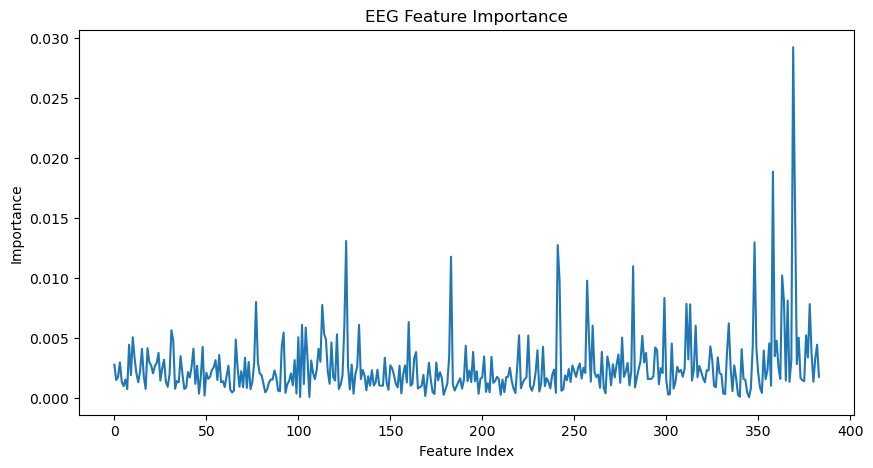

In [114]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_

plt.figure(figsize=(10,5))
plt.plot(importance)
plt.title("EEG Feature Importance")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

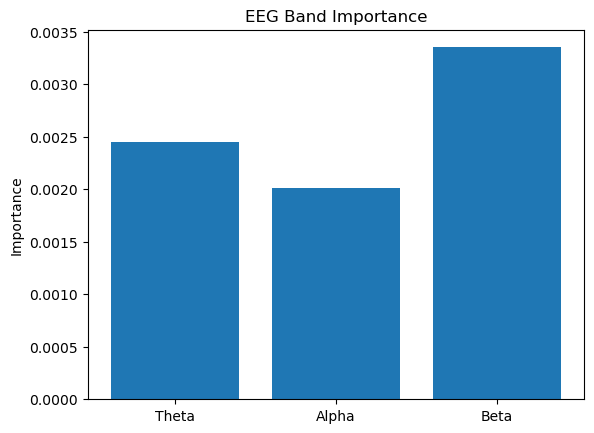

In [115]:
region_importance = importance.reshape(3,128).mean(axis=1)

bands = ["Theta","Alpha","Beta"]

plt.bar(bands, region_importance)

plt.title("EEG Band Importance")
plt.ylabel("Importance")

plt.show()

In [119]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [124]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(180, 384, 2)


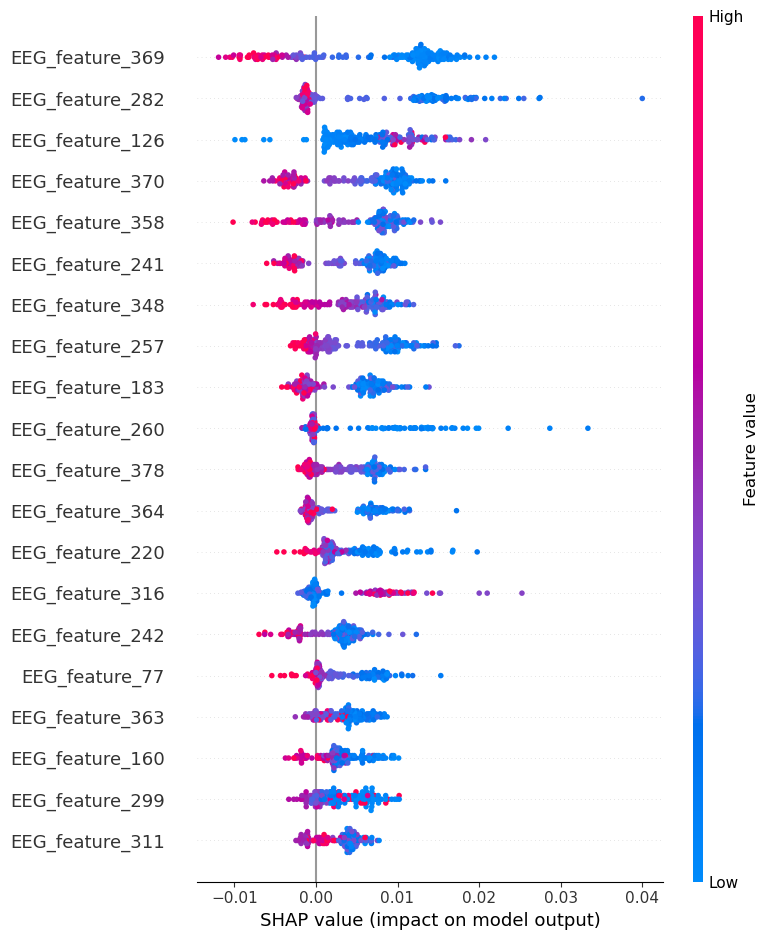

In [127]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test_scaled[:200])
feature_names = [f"EEG_feature_{i}" for i in range(384)]

shap.summary_plot(
    shap_values[:, :, 1],
    X_test_scaled[:180],
    feature_names=feature_names
)

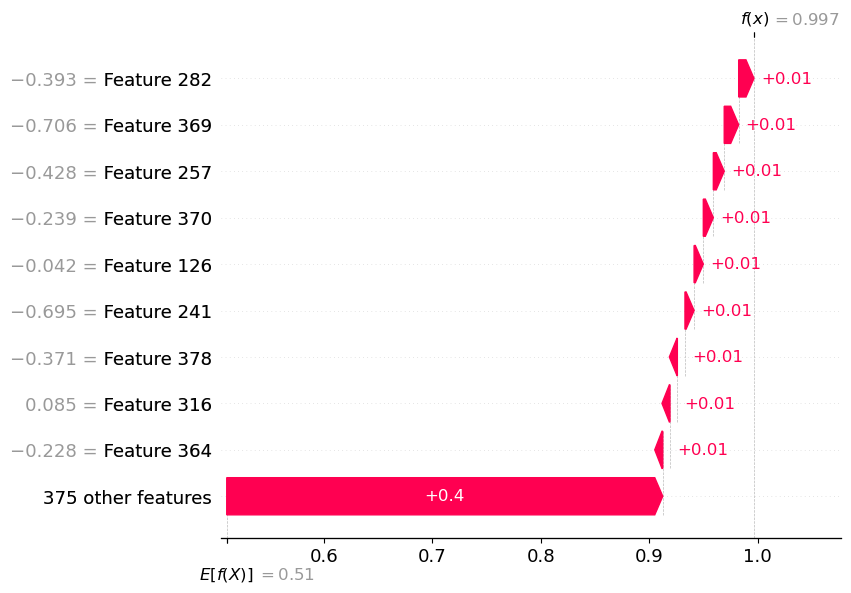

In [128]:

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test_scaled[0]
    )
)

 ROC Curve Comparison

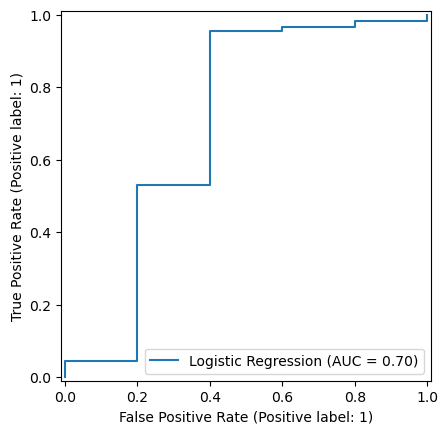

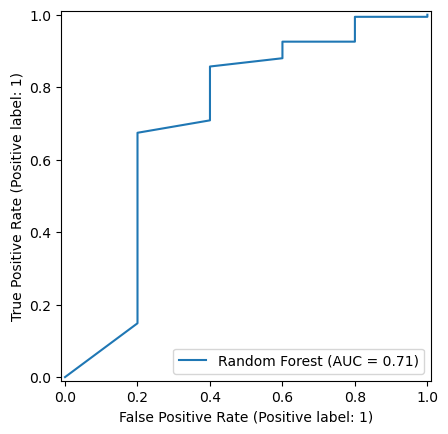

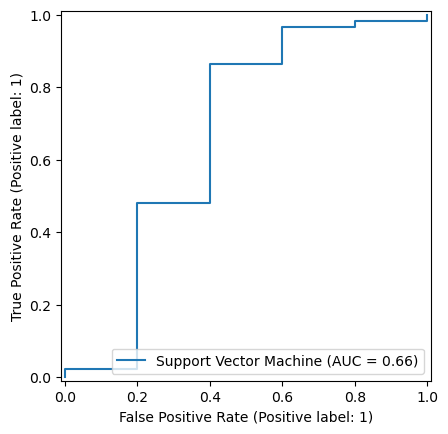

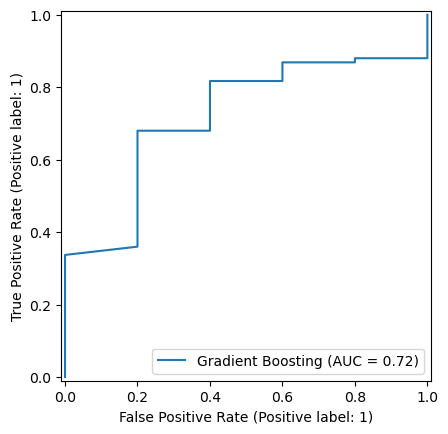

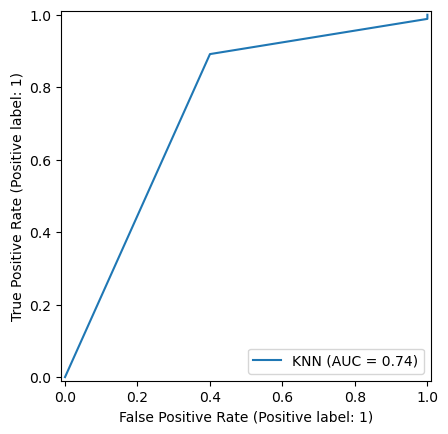

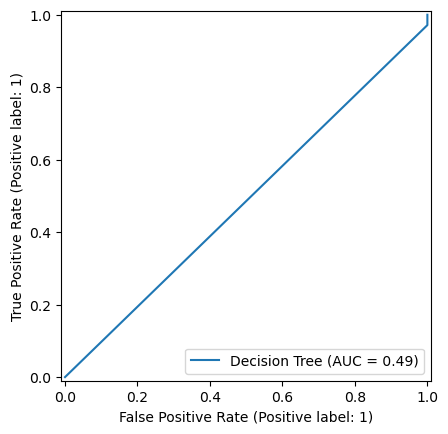

In [122]:
from sklearn.metrics import RocCurveDisplay

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    RocCurveDisplay.from_estimator(
        model,
        X_test_scaled,
        y_test,
        name=name
    )

plt.show()

Plot EEG Topographic Map

In [129]:
import numpy as np

# feature importance from Random Forest
importance = rf.feature_importances_

# reshape into (bands, channels)
importance = importance.reshape(3, 128)

# average across theta/alpha/beta
channel_importance = importance.mean(axis=0)

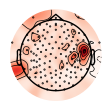

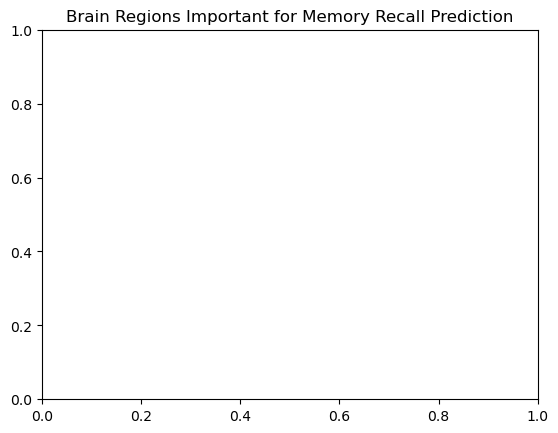

In [131]:
import mne
import matplotlib.pyplot as plt

# get electrode positions
info = raw.info

mne.viz.plot_topomap(
    channel_importance,
    info,
    cmap="Reds",
    show=True
)

plt.title("Brain Regions Important for Memory Recall Prediction")
plt.show()

Multi‑Band EEG Brain Maps

In [132]:
importance = rf.feature_importances_

# reshape into (bands, channels)
importance = importance.reshape(3, 128)

theta_importance = importance[0]
alpha_importance = importance[1]
beta_importance = importance[2]

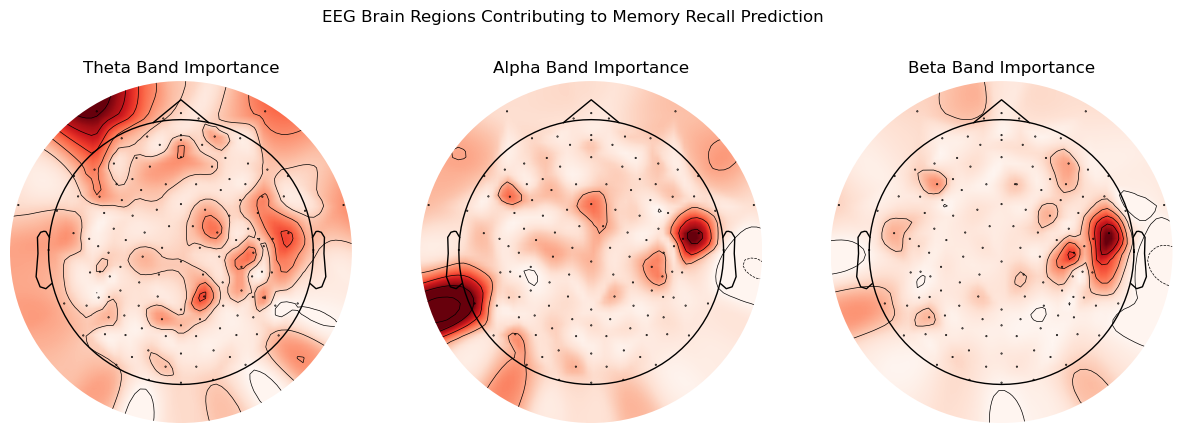

In [133]:
import matplotlib.pyplot as plt
import mne

fig, axes = plt.subplots(1, 3, figsize=(15,5))

mne.viz.plot_topomap(theta_importance, raw.info, axes=axes[0], cmap="Reds", show=False)
axes[0].set_title("Theta Band Importance")

mne.viz.plot_topomap(alpha_importance, raw.info, axes=axes[1], cmap="Reds", show=False)
axes[1].set_title("Alpha Band Importance")

mne.viz.plot_topomap(beta_importance, raw.info, axes=axes[2], cmap="Reds", show=False)
axes[2].set_title("Beta Band Importance")

plt.suptitle("EEG Brain Regions Contributing to Memory Recall Prediction")

plt.show()